# Calibration of Probabilities for Diabetes Dataset

This notebook studies the calibration of probabilistic classifiers using the Diabetes dataset from OpenML.


## 1. Import Libraries

In [1]:
"""Calibration analysis for the Diabetes dataset."""

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.datasets import fetch_openml
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, log_loss, brier_score_loss


project_root = Path.cwd().parent
sys.path.append(str(project_root))

from scripts.calibration import PlattScaling, IsotonicRegression
from scripts.visualization import (
    plot_reliability_diagram,
    compare_reliability_diagrams,
    compare_all_calibrations
)

## 2. Load the Dataset

In [2]:
diabetes = fetch_openml(
    name="diabetes",
    version=1,
    as_frame=True
)

In [3]:
print("Dataset shape:", diabetes["data"].shape)
print("Target name:", diabetes["target"].name)
print("Target classes:", diabetes["target"].unique())

Dataset shape: (768, 8)
Target name: class
Target classes: ['tested_positive', 'tested_negative']
Categories (2, str): ['tested_negative', 'tested_positive']


In [4]:
X = diabetes["data"].copy()

y = diabetes["target"].map({
    "tested_negative": 0,
    "tested_positive": 1
}).astype(int)

0 = tested_negative

1 = tested_positive

In [5]:
print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("Target values:", y.unique())

Features shape: (768, 8)
Target shape: (768,)
Target values: [1 0]


In [6]:
y = y.rename("target")

df = pd.concat(
    [X, y],
    axis=1
)

## 3. Exploratory Data Analysis (EDA)

### General describe

In [7]:
print(f"Number of observations: {df.shape[0]}")
print(f"Number of variables: {df.shape[1]}")

Number of observations: 768
Number of variables: 9


In [8]:
df.head()

,preg,plas,pres,skin,insu,mass,pedi,age,target
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   preg    768 non-null    int64  
 1   plas    768 non-null    int64  
 2   pres    768 non-null    int64  
 3   skin    768 non-null    int64  
 4   insu    768 non-null    int64  
 5   mass    768 non-null    float64
 6   pedi    768 non-null    float64
 7   age     768 non-null    int64  
 8   target  768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [10]:
df.describe()

,preg,plas,pres,skin,insu,mass,pedi,age,target
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


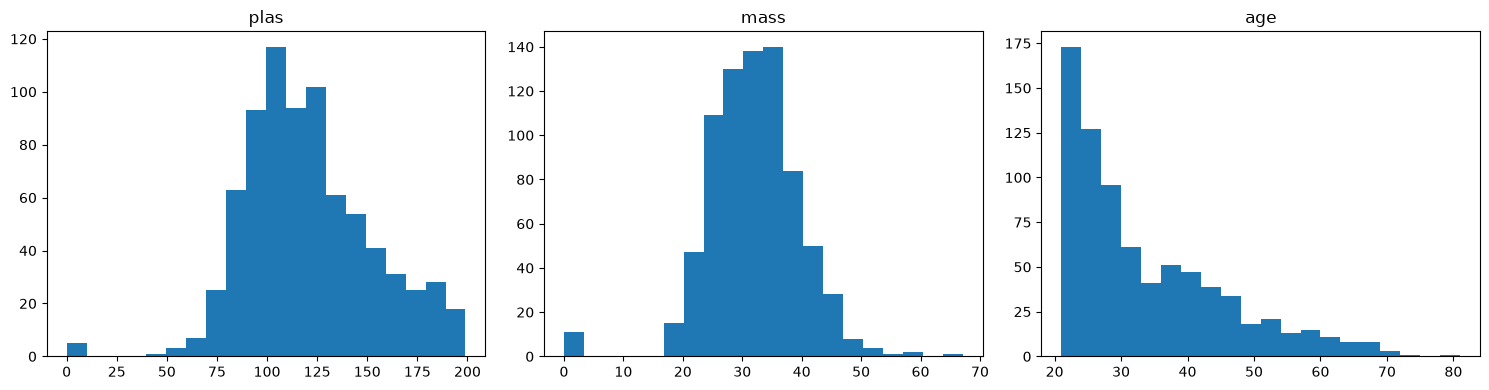

In [11]:
features = [
    "plas",
    "mass",
    "age"
]

plt.figure(figsize=(15, 4))

for i, feature in enumerate(features):

    plt.subplot(1, 3, i + 1)

    plt.hist(df[feature], bins=20)

    plt.title(feature)

plt.tight_layout()
plt.show()

### Target distribution

In [12]:
target_summary = pd.DataFrame({
    "Count": df["target"].value_counts().sort_index(),
    "Percentage": (
        df["target"]
        .value_counts(normalize=True)
        .sort_index() * 100
    ).round(2)
})

target_summary.index = [
    "Tested Negative",
    "Tested Positive"
]

display(target_summary)

,Count,Percentage
Tested Negative,500,65.1
Tested Positive,268,34.9


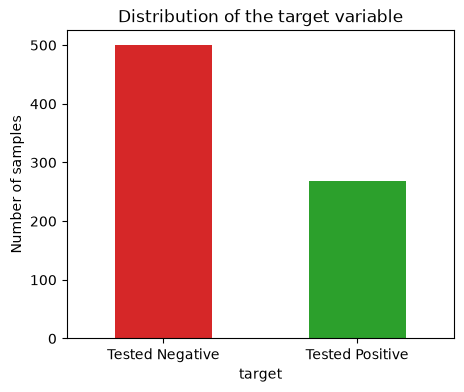

In [13]:
plt.figure(figsize=(5, 4))

df["target"].value_counts().sort_index().plot(
    kind="bar",
    color=["#d62728", "#2ca02c"]
)

plt.xticks(
    [0, 1],
    ["Tested Negative", "Tested Positive"],
    rotation=0
)

plt.ylabel("Number of samples")
plt.title("Distribution of the target variable")

plt.show()

### Missing values

In [14]:
df.isnull().sum()

preg      0
plas      0
pres      0
skin      0
insu      0
mass      0
pedi      0
age       0
target    0
dtype: int64

In [15]:
(df == 0).sum()

preg      111
plas        5
pres       35
skin      227
insu      374
mass       11
pedi        0
age         0
target    500
dtype: int64

Although the dataset contains no explicit missing values, some features contain zero values that are not physiologically plausible, such as glucose concentration, blood pressure, skin thickness, insulin, and BMI. These zeros are therefore treated as missing values and imputed before model training.

I will analise them in data preprocessing.

### Correlation matrix

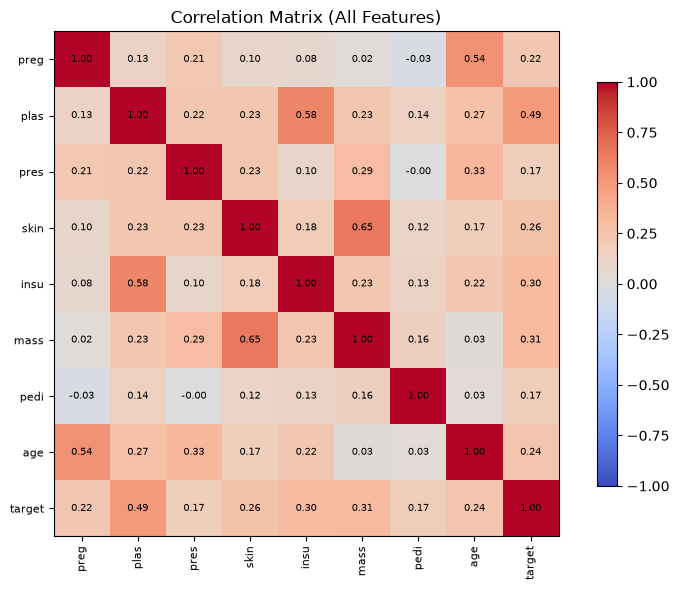

In [23]:
corr = df.corr()

plt.figure(figsize=(8, 6))

plt.imshow(
    corr,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    interpolation="nearest"
)

plt.colorbar(shrink=0.8)

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=90,
    fontsize=8
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns,
    fontsize=8
)

for i in range(len(corr)):
    for j in range(len(corr.columns)):
        plt.text(
            j,
            i,
            f"{corr.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=7
        )

plt.title("Correlation Matrix (All Features)", fontsize=12)

plt.tight_layout()
plt.show()

The target variable shows a moderate class imbalance, with approximately 65% negative and 35% positive cases. The correlation matrix indicates that plasma glucose concentration (plas) has the strongest correlation with the target (0.49), followed by body mass index (mass) and insulin (insu). Some features also show moderate correlations with each other. At this stage, the EDA is based on the original data: implausible zero values in some clinical variables have not yet been treated and will be handled during the preprocessing step using imputation.

## 4. Data Preprocessing

### Missing values

In [17]:
columns_with_missing_zeros = [
    "plas",
    "pres",
    "skin",
    "insu",
    "mass"
]

df[columns_with_missing_zeros] = (
    df[columns_with_missing_zeros].replace(0, np.nan)
)

In [18]:
df.isnull().sum()

preg        0
plas        5
pres       35
skin      227
insu      374
mass       11
pedi        0
age         0
target      0
dtype: int64

In [19]:
X = df.drop(columns="target")
y = df["target"]

In [20]:
mice_imputer = IterativeImputer(
    random_state=42,
    max_iter=10
)

X_imputed = mice_imputer.fit_transform(X)

In [21]:
X = pd.DataFrame(
    X_imputed,
    columns=X.columns,
    index=X.index
)